In [186]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    log_loss
)
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import PrecisionRecallDisplay
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_curve, roc_auc_score
import optuna
from sklearn.metrics import confusion_matrix

print(pd.__version__)

2.3.3


In [18]:
df = pd.read_csv("gold_mortgage_202609232018.csv")

C:\Users\usuario\AppData\Local\Temp\ipykernel_35720\3759643464.py:1: DtypeWarning: Columns (21) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("gold_mortgage_202609232018.csv")


In [8]:
df.shape

(10451383, 25)

<Axes: >

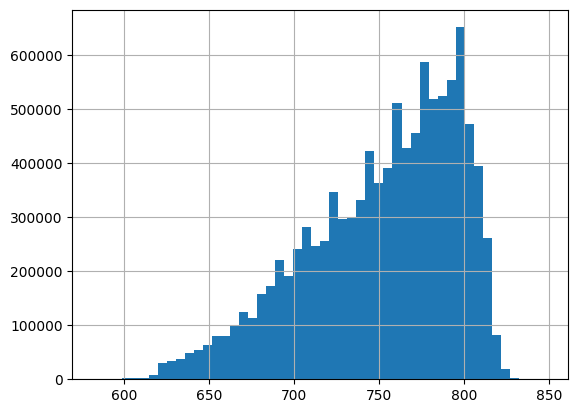

In [10]:
df["credit_score"].hist(bins=50)

In [20]:
df_loan = df.copy()
df_loan = df_loan.drop(columns=[
    "monthly_reporting_period",
    "zero_balance_code",
    "zero_balance_effective_date"
])


In [19]:
df.columns.tolist()

['credit_score',
 'first_payment_date',
 'first_time_homebuyer_flag',
 'maturity_date',
 'MSA',
 'mi_percentage',
 'number_of_units',
 'occupancy_status',
 'original_cltv',
 'original_dti',
 'original_upb',
 'original_ltv',
 'original_interest_rate',
 'property_state',
 'property_type',
 'postal_code',
 'loan_sequence_number',
 'loan_purpose',
 'original_loan_term',
 'number_of_borrowers',
 'monthly_reporting_period',
 'current_loan_delinquency_status',
 'zero_balance_code',
 'zero_balance_effective_date',
 'original_dti_missing']

In [33]:
df_loan["current_loan_delinquency_status"] = pd.to_numeric(
    df_loan["current_loan_delinquency_status"],
    errors="coerce"
)

df_loan = df_loan.groupby(
    "loan_sequence_number",
    as_index=False
).agg({
    "credit_score": "first",
    "first_payment_date": "first",
    "first_time_homebuyer_flag": "first",
    "maturity_date": "first",
    "MSA": "first",
    "mi_percentage": "first",
    "number_of_units": "first",
    "occupancy_status": "first",
    "original_cltv": "first",
    "original_dti": "first",
    "original_upb": "first",
    "original_ltv": "first",
    "original_interest_rate": "first",
    "property_state": "first",
    "property_type": "first",
    "postal_code": "first",
    "loan_purpose": "first",
    "original_loan_term": "first",
    "number_of_borrowers": "first",
    "current_loan_delinquency_status": "max",
    "original_dti_missing": "first"
})

In [43]:
df_loan.shape
df_loan["current_loan_delinquency_status"].value_counts()

current_loan_delinquency_status
0.0     225148
1.0      16395
2.0       2686
3.0       1303
5.0        795
4.0        785
6.0        539
7.0        349
8.0        319
9.0        231
11.0       214
10.0       207
12.0       201
13.0       136
14.0       127
15.0        86
17.0        81
16.0        68
18.0        51
20.0        44
19.0        43
21.0        26
22.0        18
24.0        16
25.0        13
23.0        10
27.0         8
29.0         7
31.0         6
28.0         6
32.0         3
26.0         3
33.0         2
30.0         2
40.0         1
45.0         1
38.0         1
56.0         1
36.0         1
50.0         1
46.0         1
35.0         1
Name: count, dtype: int64

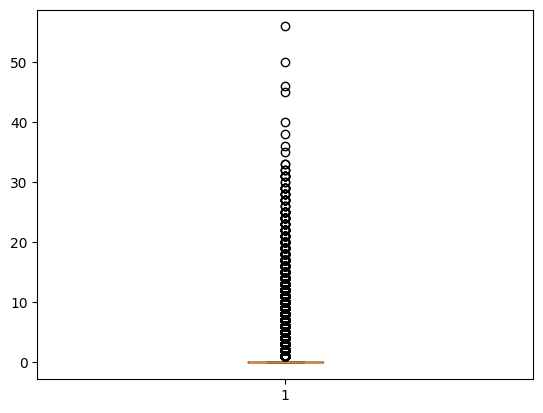

In [51]:
### hacemos un boxplot de la variable current_loan_delinquency_status

plt.boxplot(df_loan['current_loan_delinquency_status'])


plt.show()

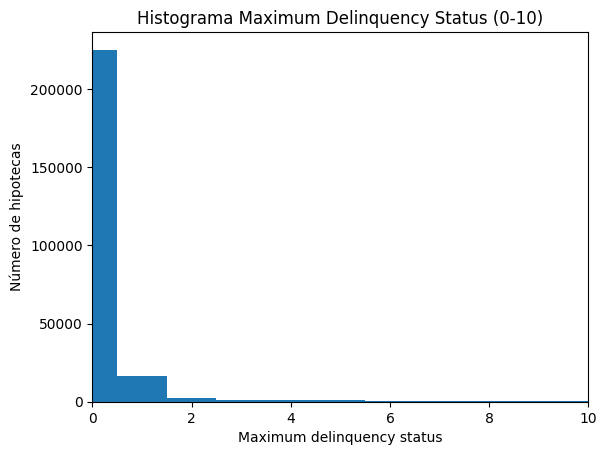

In [57]:
### Histograma del Maximum Delinquency Status (0-10)

plt.hist(
    df_loan['current_loan_delinquency_status'],
    bins=range(0, 12),
    align='left'
)

plt.xlim(0, 10)
plt.title('Histograma Maximum Delinquency Status (0-10)')
plt.xlabel('Maximum delinquency status')
plt.ylabel('Número de hipotecas')

plt.show()

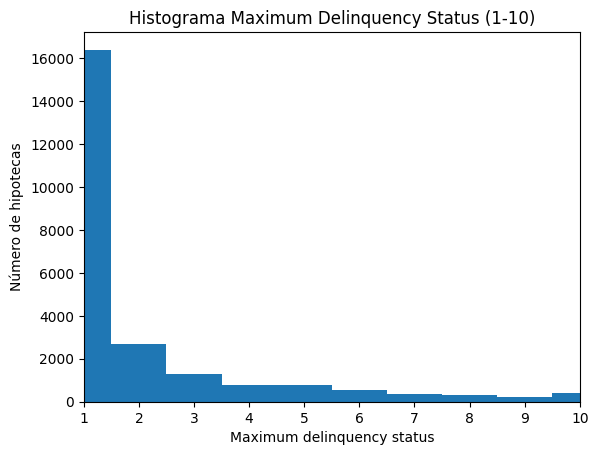

In [58]:
### Histograma del Maximum Delinquency Status (1-10)

plt.hist(
    df_loan['current_loan_delinquency_status'],
    bins=range(1, 12),
    align='left'
)

plt.xlim(1, 10)
plt.title('Histograma Maximum Delinquency Status (1-10)')
plt.xlabel('Maximum delinquency status')
plt.ylabel('Número de hipotecas')

plt.show()

In [60]:
df_loan['delinquency'] = (
    df_loan['current_loan_delinquency_status'] >= 1
).astype(int)

df_loan['delinquency'].value_counts()

delinquency
0    225148
1     24788
Name: count, dtype: int64

In [66]:
df_loan['first_time_homebuyer_flag'] = (
    df_loan['first_time_homebuyer_flag']
    .map({'Y': 1, 'N': 0})
)

In [71]:
df_loan['primary_residence'] = (
    df_loan['occupancy_status'] == 'P'
).astype(int)

df_loan['second_home'] = (
    df_loan['occupancy_status'] == 'S'
).astype(int)

df_loan['investment_property'] = (
    df_loan['occupancy_status'] == 'I'
).astype(int)

df_loan = df_loan.drop(columns=['occupancy_status'])

In [76]:
df_loan['single_family'] = (
    df_loan['property_type'] == 'SF'
).astype(int)

df_loan['planned_unit_development'] = (
    df_loan['property_type'] == 'PU'
).astype(int)

df_loan['condominium'] = (
    df_loan['property_type'] == 'CO'
).astype(int)

df_loan['manufactured_housing'] = (
    df_loan['property_type'] == 'MH'
).astype(int)

df_loan['cooperative'] = (
    df_loan['property_type'] == 'CP'
).astype(int)

df_loan = df_loan.drop(columns=['property_type'])

In [80]:
df_loan['purchase'] = (
    df_loan['loan_purpose'] == 'P'
).astype(int)

df_loan['cash_out_refinance'] = (
    df_loan['loan_purpose'] == 'C'
).astype(int)

df_loan['no_cash_out_refinance'] = (
    df_loan['loan_purpose'] == 'N'
).astype(int)

df_loan = df_loan.drop(columns=['loan_purpose'])

In [86]:
df_loan = df_loan.drop(columns=['original_dti_missing'])

In [92]:
df_loan['postal_code'] = df_loan['postal_code'].astype('object')
df_loan['MSA'] = df_loan['MSA'].astype('object')

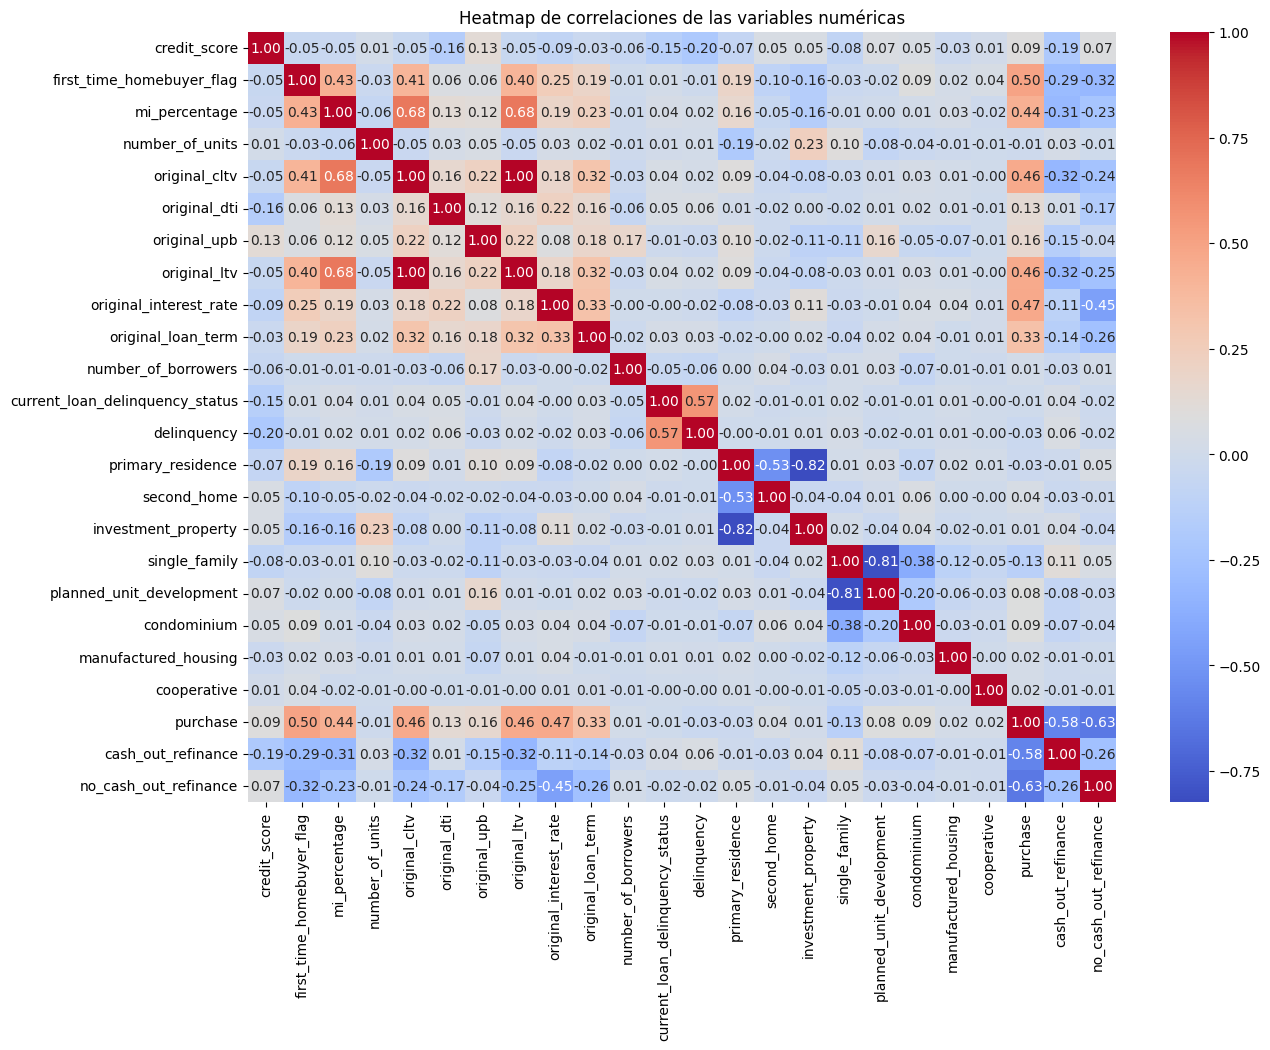

In [93]:
# Seleccionamos variables numéricas
df_corr = df_loan.select_dtypes(include='number')

# Matriz de correlaciones
corr = df_corr.corr()

# Heatmap
plt.figure(figsize=(14, 10))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Heatmap de correlaciones de las variables numéricas')
plt.show()

In [110]:
df_loan_ml = df_loan.select_dtypes(include='number').copy()
df_loan_ml.dtypes

df_loan_ml = df_loan_ml.drop(
    columns=['current_loan_delinquency_status']
)

In [111]:
X = df_loan_ml.drop(columns=['delinquency'])
y = df_loan_ml['delinquency']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [112]:
modelo_logistico = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('logistic', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ))
])

In [113]:
modelo_logistico.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](22,)","['credit_score','first_time_homebuyer_flag','mi_percentage',...,'purchase', 'cash_out_refinance','no_cash_out_refinance']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,22
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace all

In [114]:
y_pred = modelo_logistico.predict(X_test)

y_prob = modelo_logistico.predict_proba(X_test)[:, 1]

In [115]:
accuracy = accuracy_score(y_test, y_pred)
balanced_acc = balanced_accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)
logloss = log_loss(y_test, y_prob)

print(f"Accuracy:           {accuracy:.4f}")
print(f"Balanced Accuracy:  {balanced_acc:.4f}")
print(f"Precision:          {precision:.4f}")
print(f"Recall:             {recall:.4f}")
print(f"F1-score:           {f1:.4f}")
print(f"ROC-AUC:            {roc_auc:.4f}")
print(f"PR-AUC:             {pr_auc:.4f}")
print(f"Log Loss:           {logloss:.4f}")

Accuracy:           0.6592
Balanced Accuracy:  0.6527
Precision:          0.1730
Recall:             0.6446
F1-score:           0.2728
ROC-AUC:            0.7077
PR-AUC:             0.2127
Log Loss:           0.6261


In [116]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=['No delinquency', 'Delinquency']
    )
)

                precision    recall  f1-score   support

No delinquency       0.94      0.66      0.78     45030
   Delinquency       0.17      0.64      0.27      4958

      accuracy                           0.66     49988
     macro avg       0.56      0.65      0.53     49988
  weighted avg       0.87      0.66      0.73     49988



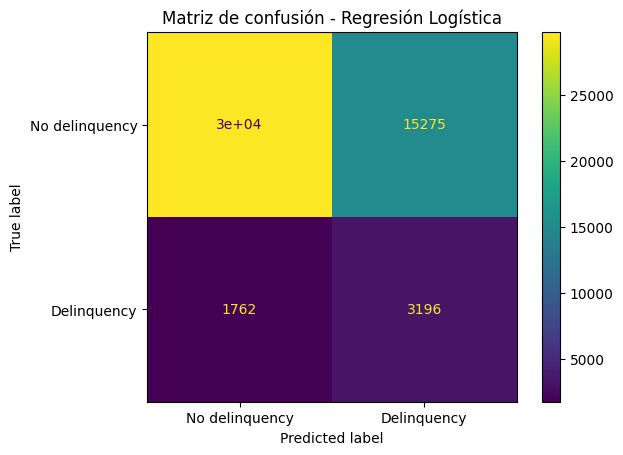

In [117]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=['No delinquency', 'Delinquency']
)

plt.title('Matriz de confusión - Regresión Logística')
plt.show()

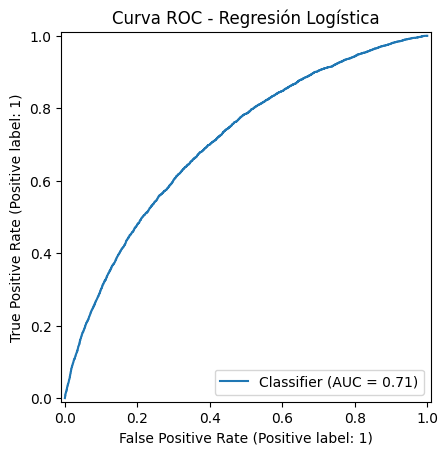

In [122]:
RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title('Curva ROC - Regresión Logística')
plt.show()

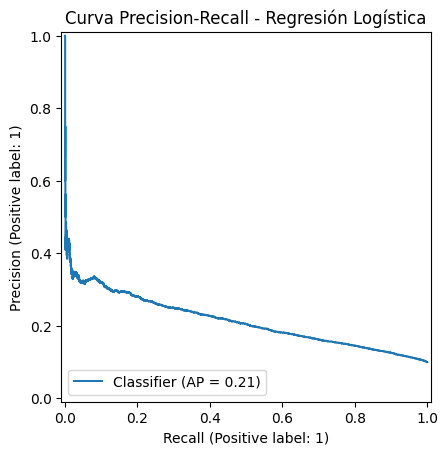

In [124]:
PrecisionRecallDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title('Curva Precision-Recall - Regresión Logística')
plt.show()

In [126]:
modelo_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

In [127]:
modelo_rf.fit(X_train, y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [128]:
y_pred_rf = modelo_rf.predict(X_test)
y_prob_rf = modelo_rf.predict_proba(X_test)[:, 1]

In [129]:
print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=['No delinquency', 'Delinquency']
    )
)

                precision    recall  f1-score   support

No delinquency       0.90      1.00      0.95     45030
   Delinquency       0.33      0.01      0.02      4958

      accuracy                           0.90     49988
     macro avg       0.62      0.50      0.48     49988
  weighted avg       0.84      0.90      0.85     49988



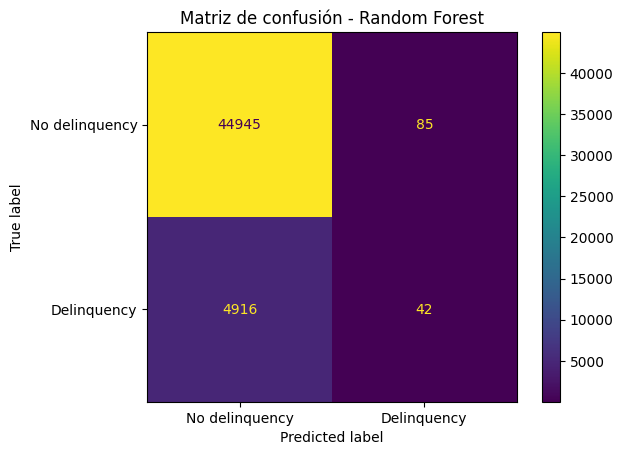

In [130]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    display_labels=['No delinquency', 'Delinquency']
)

plt.title('Matriz de confusión - Random Forest')
plt.show()

In [131]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Balanced accuracy:", balanced_accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print("PR-AUC:", average_precision_score(y_test, y_prob_rf))

Accuracy: 0.899955989437465
Balanced accuracy: 0.5032917636281563
Precision: 0.33070866141732286
Recall: 0.008471157724889069
F1: 0.016519174041297935
ROC-AUC: 0.6710756855476296
PR-AUC: 0.18142999466694024


In [135]:
modelo_xgb = XGBClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)

modelo_xgb.fit(X_train, y_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [136]:
y_pred_xgb = modelo_xgb.predict(X_test)
y_prob_xgb = modelo_xgb.predict_proba(X_test)[:, 1]

In [137]:
print(
    classification_report(
        y_test,
        y_pred_xgb,
        target_names=['No delinquency', 'Delinquency']
    )
)

                precision    recall  f1-score   support

No delinquency       0.90      1.00      0.95     45030
   Delinquency       0.28      0.01      0.01      4958

      accuracy                           0.90     49988
     macro avg       0.59      0.50      0.48     49988
  weighted avg       0.84      0.90      0.85     49988



In [139]:
modelo_lgbm = LGBMClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

modelo_lgbm.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 19830, number of negative: 180118
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006248 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1094
[LightGBM] [Info] Number of data points in the train set: 199948, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.099176 -> initscore=-2.206416
[LightGBM] [Info] Start training from score -2.206416


,random_state,42
,n_jobs,-1
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0


In [141]:
y_pred_lgbm = modelo_lgbm.predict(X_test)
y_prob_lgbm = modelo_lgbm.predict_proba(X_test)[:, 1]

In [142]:
print(
    classification_report(
        y_test,
        y_pred_lgbm,
        target_names=['No delinquency', 'Delinquency']
    )
)

                precision    recall  f1-score   support

No delinquency       0.90      1.00      0.95     45030
   Delinquency       0.43      0.00      0.00      4958

      accuracy                           0.90     49988
     macro avg       0.66      0.50      0.47     49988
  weighted avg       0.85      0.90      0.85     49988



In [143]:
modelo_rf_bal = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

In [144]:
modelo_rf_bal.fit(X_train, y_train)

y_pred_rf_bal = modelo_rf_bal.predict(X_test)
y_prob_rf_bal = modelo_rf_bal.predict_proba(X_test)[:, 1]

In [145]:
print(
    classification_report(
        y_test,
        y_pred_rf_bal,
        target_names=['No delinquency', 'Delinquency']
    )
)

                precision    recall  f1-score   support

No delinquency       0.91      0.97      0.94     45030
   Delinquency       0.24      0.10      0.14      4958

      accuracy                           0.88     49988
     macro avg       0.57      0.53      0.54     49988
  weighted avg       0.84      0.88      0.86     49988



In [146]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print(scale_pos_weight)

9.083106404437721


In [147]:
modelo_xgb_bal = XGBClassifier(
    n_estimators=100,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)

modelo_xgb_bal.fit(X_train, y_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [148]:
y_pred_xgb_bal = modelo_xgb_bal.predict(X_test)
y_prob_xgb_bal = modelo_xgb_bal.predict_proba(X_test)[:, 1]

In [149]:
print(
    classification_report(
        y_test,
        y_pred_xgb_bal,
        target_names=['No delinquency', 'Delinquency']
    )
)

                precision    recall  f1-score   support

No delinquency       0.94      0.67      0.78     45030
   Delinquency       0.17      0.62      0.27      4958

      accuracy                           0.67     49988
     macro avg       0.56      0.64      0.53     49988
  weighted avg       0.86      0.67      0.73     49988



In [150]:
modelo_lgbm_bal = LGBMClassifier(
    n_estimators=100,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1
)

In [151]:
modelo_lgbm_bal.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 19830, number of negative: 180118
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009381 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1094
[LightGBM] [Info] Number of data points in the train set: 199948, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.099176 -> initscore=-2.206416
[LightGBM] [Info] Start training from score -2.206416


,random_state,42
,n_jobs,-1
,scale_pos_weight,np.float64(9.083106404437721)
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None


In [152]:
y_pred_lgbm_bal = modelo_lgbm_bal.predict(X_test)
y_prob_lgbm_bal = modelo_lgbm_bal.predict_proba(X_test)[:, 1]

In [153]:
print(
    classification_report(
        y_test,
        y_pred_lgbm_bal,
        target_names=['No delinquency', 'Delinquency']
    )
)

                precision    recall  f1-score   support

No delinquency       0.94      0.65      0.77     45030
   Delinquency       0.17      0.65      0.27      4958

      accuracy                           0.65     49988
     macro avg       0.56      0.65      0.52     49988
  weighted avg       0.87      0.65      0.72     49988



In [156]:
modelo_logistico_2 = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('logistic', LogisticRegression(
        class_weight={0: 1, 1: 3},
        max_iter=1000,
        random_state=42
    ))
])

modelo_logistico_2.fit(X_train, y_train)

y_pred_log_2 = modelo_logistico_2.predict(X_test)
y_prob_log_2 = modelo_logistico_2.predict_proba(X_test)[:, 1]

In [157]:
print(
    classification_report(
        y_test,
        y_pred_log_2,
        target_names=['No delinquency', 'Delinquency']
    )
)

                precision    recall  f1-score   support

No delinquency       0.91      0.96      0.93     45030
   Delinquency       0.29      0.15      0.20      4958

      accuracy                           0.88     49988
     macro avg       0.60      0.56      0.57     49988
  weighted avg       0.85      0.88      0.86     49988



In [160]:
thresholds = [0.50, 0.45, 0.40, 0.35, 0.30, 0.25, 0.20]

In [162]:
modelos = {
    'Logistic Regression': y_prob,
    'XGBoost': y_prob_xgb_bal,
    'LightGBM': y_prob_lgbm_bal
}

for nombre, probabilidades in modelos.items():
    
    print(f"\n===== {nombre} =====")
    
    for threshold in thresholds:
        
        y_pred = (probabilidades >= threshold).astype(int)
        
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        
        print(
            f"Threshold {threshold:.2f} | "
            f"Precision: {precision:.2f} | "
            f"Recall: {recall:.2f} | "
            f"F1: {f1:.2f}"
        )


===== Logistic Regression =====
Threshold 0.50 | Precision: 0.17 | Recall: 0.64 | F1: 0.27
Threshold 0.45 | Precision: 0.16 | Recall: 0.72 | F1: 0.26
Threshold 0.40 | Precision: 0.14 | Recall: 0.81 | F1: 0.24
Threshold 0.35 | Precision: 0.13 | Recall: 0.87 | F1: 0.23
Threshold 0.30 | Precision: 0.12 | Recall: 0.92 | F1: 0.21
Threshold 0.25 | Precision: 0.11 | Recall: 0.97 | F1: 0.20
Threshold 0.20 | Precision: 0.10 | Recall: 0.99 | F1: 0.19

===== XGBoost =====
Threshold 0.50 | Precision: 0.17 | Recall: 0.62 | F1: 0.27
Threshold 0.45 | Precision: 0.16 | Recall: 0.69 | F1: 0.26
Threshold 0.40 | Precision: 0.15 | Recall: 0.76 | F1: 0.24
Threshold 0.35 | Precision: 0.14 | Recall: 0.82 | F1: 0.23
Threshold 0.30 | Precision: 0.13 | Recall: 0.87 | F1: 0.22
Threshold 0.25 | Precision: 0.12 | Recall: 0.91 | F1: 0.21
Threshold 0.20 | Precision: 0.11 | Recall: 0.95 | F1: 0.20

===== LightGBM =====
Threshold 0.50 | Precision: 0.17 | Recall: 0.65 | F1: 0.27
Threshold 0.45 | Precision: 0.16 | Reca

In [164]:
# Threshold 0.40
y_pred_log_04 = (y_prob >= 0.40).astype(int)

# Classification report
print(classification_report(
    y_test,
    y_pred_log_04,
    target_names=['No delinquency', 'Delinquency'],
    digits=2
))

                precision    recall  f1-score   support

No delinquency       0.96      0.47      0.63     45030
   Delinquency       0.14      0.81      0.24      4958

      accuracy                           0.50     49988
     macro avg       0.55      0.64      0.44     49988
  weighted avg       0.88      0.50      0.59     49988



In [165]:
roc_auc_xgb = roc_auc_score(y_test, y_prob_xgb_bal)

print(f"ROC-AUC XGBoost balanceado: {roc_auc_xgb:.4f}")

ROC-AUC XGBoost balanceado: 0.6945


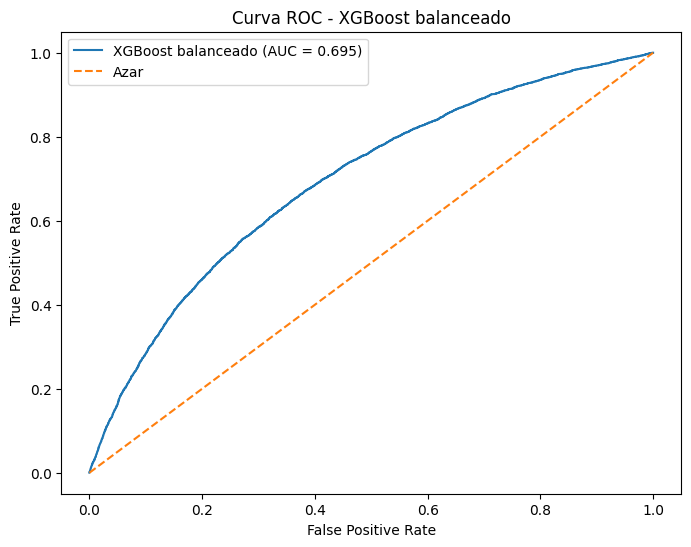

In [169]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob_xgb_bal)

roc_auc = roc_auc_score(y_test, y_prob_xgb_bal)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f'XGBoost balanceado (AUC = {roc_auc:.3f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Azar'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC - XGBoost balanceado')
plt.legend()
plt.show()

In [171]:
X_train_opt, X_val, y_train_opt, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

In [172]:
def objective_precision(trial):

    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 400),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float(
            'learning_rate', 0.01, 0.2, log=True
        ),
        'min_child_weight': trial.suggest_int(
            'min_child_weight', 1, 10
        ),
        'subsample': trial.suggest_float(
            'subsample', 0.6, 1.0
        ),
        'colsample_bytree': trial.suggest_float(
            'colsample_bytree', 0.6, 1.0
        ),
        'gamma': trial.suggest_float(
            'gamma', 0, 5
        ),
        'reg_alpha': trial.suggest_float(
            'reg_alpha', 0, 5
        ),
        'reg_lambda': trial.suggest_float(
            'reg_lambda', 0.1, 10
        )
    }

    modelo = XGBClassifier(
        **params,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=-1,
        eval_metric='logloss'
    )

    modelo.fit(
        X_train_opt,
        y_train_opt
    )

    # Probabilidades
    y_prob = modelo.predict_proba(X_val)[:, 1]

    # Threshold = 0.50
    y_pred = (y_prob >= 0.50).astype(int)

    # Precision de la clase 1
    precision = precision_score(
        y_val,
        y_pred,
        pos_label=1
    )

    return precision

In [173]:
study_precision = optuna.create_study(
    direction='maximize'
)

study_precision.optimize(
    objective_precision,
    n_trials=30
)

[I 2026-09-28 14:12:45,167] A new study created in memory with name: no-name-87f2dbdb-c072-4c29-98ba-87f5aaf521b1
[I 2026-09-28 14:12:49,852] Trial 0 finished with value: 0.17448504983388705 and parameters: {'n_estimators': 324, 'max_depth': 5, 'learning_rate': 0.014199626851608114, 'min_child_weight': 5, 'subsample': 0.8069351400556128, 'colsample_bytree': 0.8511668718573718, 'gamma': 1.9445583448657788, 'reg_alpha': 1.9086485307137901, 'reg_lambda': 6.1763740005087655}. Best is trial 0 with value: 0.17448504983388705.
[I 2026-09-28 14:12:56,221] Trial 1 finished with value: 0.1826930420835561 and parameters: {'n_estimators': 384, 'max_depth': 8, 'learning_rate': 0.03452190412936337, 'min_child_weight': 1, 'subsample': 0.6881414866393296, 'colsample_bytree': 0.7442745382942529, 'gamma': 4.3266126028594085, 'reg_alpha': 4.950120397747997, 'reg_lambda': 4.489825860562297}. Best is trial 1 with value: 0.1826930420835561.
[I 2026-09-28 14:12:58,106] Trial 2 finished with value: 0.17529372

In [174]:
print("Mejor precision:")
print(study_precision.best_value)

print("\nMejores hiperparámetros:")
print(study_precision.best_params)

Mejor precision:
0.19061865583929907

Mejores hiperparámetros:
{'n_estimators': 249, 'max_depth': 10, 'learning_rate': 0.1105452377983182, 'min_child_weight': 6, 'subsample': 0.8466668887816309, 'colsample_bytree': 0.9433508335299168, 'gamma': 2.273781323585032, 'reg_alpha': 2.548887828585916, 'reg_lambda': 8.243601820842146}


In [175]:
modelo_xgb_precision = XGBClassifier(
    **study_precision.best_params,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)

modelo_xgb_precision.fit(
    X_train,
    y_train
)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.9433508335299168
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [176]:
y_prob_xgb_precision = (
    modelo_xgb_precision.predict_proba(X_test)[:, 1]
)

y_pred_xgb_precision = (
    y_prob_xgb_precision >= 0.50
).astype(int)

print(classification_report(
    y_test,
    y_pred_xgb_precision,
    target_names=['No delinquency', 'Delinquency'],
    digits=2
))

                precision    recall  f1-score   support

No delinquency       0.93      0.77      0.85     45030
   Delinquency       0.19      0.47      0.27      4958

      accuracy                           0.74     49988
     macro avg       0.56      0.62      0.56     49988
  weighted avg       0.86      0.74      0.79     49988



In [177]:
def objective(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 400),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float(
            "learning_rate", 0.01, 0.2, log=True
        ),
        "min_child_weight": trial.suggest_int(
            "min_child_weight", 1, 10
        ),
        "subsample": trial.suggest_float(
            "subsample", 0.6, 1.0
        ),
        "colsample_bytree": trial.suggest_float(
            "colsample_bytree", 0.6, 1.0
        ),
        "gamma": trial.suggest_float(
            "gamma", 0, 5
        ),
        "reg_alpha": trial.suggest_float(
            "reg_alpha", 0, 5
        ),
        "reg_lambda": trial.suggest_float(
            "reg_lambda", 0.1, 10
        ),
        "scale_pos_weight": scale_pos_weight,
        "random_state": 42,
        "n_jobs": -1,
        "eval_metric": "logloss"
    }

    model = XGBClassifier(**params)

    model.fit(X_train_opt, y_train_opt)

    y_pred = model.predict(X_val)

    f1 = f1_score(
        y_val,
        y_pred,
        pos_label=1
    )

    return f1


study_f1 = optuna.create_study(
    direction="maximize",
    study_name="xgboost_f1_class1"
)

study_f1.optimize(
    objective,
    n_trials=30
)

[I 2026-09-28 17:14:57,603] A new study created in memory with name: xgboost_f1_class1
[I 2026-09-28 17:15:00,909] Trial 0 finished with value: 0.27811687277745345 and parameters: {'n_estimators': 353, 'max_depth': 3, 'learning_rate': 0.11527219404852272, 'min_child_weight': 9, 'subsample': 0.8106984678786993, 'colsample_bytree': 0.9798922740891258, 'gamma': 2.5183965082991717, 'reg_alpha': 4.388339908342649, 'reg_lambda': 4.352681618213902}. Best is trial 0 with value: 0.27811687277745345.
[I 2026-09-28 17:15:07,786] Trial 1 finished with value: 0.27134123885983646 and parameters: {'n_estimators': 350, 'max_depth': 10, 'learning_rate': 0.05427188526204724, 'min_child_weight': 5, 'subsample': 0.6589242040834308, 'colsample_bytree': 0.807257029699828, 'gamma': 0.0436755713208703, 'reg_alpha': 3.3986887117359643, 'reg_lambda': 0.2176195502761603}. Best is trial 0 with value: 0.27811687277745345.
[I 2026-09-28 17:15:13,529] Trial 2 finished with value: 0.2823501707288355 and parameters: {

In [180]:
print("Mejor F1 clase 1:")
print(study_f1.best_value)

print("\nMejores hiperparámetros:")
print(study_f1.best_params)

Mejor F1 clase 1:
0.2829706233308711

Mejores hiperparámetros:
{'n_estimators': 169, 'max_depth': 9, 'learning_rate': 0.01817427399319929, 'min_child_weight': 1, 'subsample': 0.8713796085614073, 'colsample_bytree': 0.8582319939028327, 'gamma': 4.338923913254693, 'reg_alpha': 2.1595774630425977, 'reg_lambda': 8.180218548931519}


In [181]:
modelo_xgb_f1 = XGBClassifier(
    **study_f1.best_params,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)

modelo_xgb_f1.fit(
    X_train,
    y_train
)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8582319939028327
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [182]:
y_prob_xgb_f1 = (
    modelo_xgb_f1.predict_proba(X_test)[:, 1]
)

y_pred_xgb_f1 = (
    y_prob_xgb_f1 >= 0.50
).astype(int)

print(classification_report(
    y_test,
    y_pred_xgb_f1,
    target_names=['No delinquency', 'Delinquency'],
    digits=2
))

                precision    recall  f1-score   support

No delinquency       0.94      0.69      0.79     45030
   Delinquency       0.18      0.62      0.28      4958

      accuracy                           0.68     49988
     macro avg       0.56      0.65      0.54     49988
  weighted avg       0.87      0.68      0.74     49988



Matriz de confusión:
[[30877 14153]
 [ 1889  3069]]

Resultados:
Verdaderos negativos (TN): 30877
Falsos positivos (FP): 14153
Falsos negativos (FN): 1889
Verdaderos positivos (TP): 3069


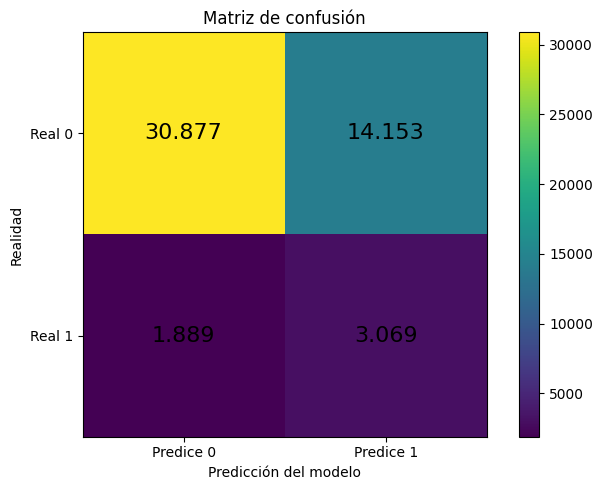

In [187]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_xgb_f1)

print("Matriz de confusión:")
print(cm)

# Extraer valores
TN, FP, FN, TP = cm.ravel()

print("\nResultados:")
print(f"Verdaderos negativos (TN): {TN}")
print(f"Falsos positivos (FP): {FP}")
print(f"Falsos negativos (FN): {FN}")
print(f"Verdaderos positivos (TP): {TP}")


# =========================================================
# VISUALIZACIÓN
# =========================================================

fig, ax = plt.subplots(figsize=(7, 5))

im = ax.imshow(cm)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

ax.set_xticklabels(["Predice 0", "Predice 1"])
ax.set_yticklabels(["Real 0", "Real 1"])

ax.set_xlabel("Predicción del modelo")
ax.set_ylabel("Realidad")

ax.set_title("Matriz de confusión")

# Escribir los valores dentro de la matriz
for i in range(2):
    for j in range(2):
        ax.text(
            j,
            i,
            f"{cm[i, j]:,}".replace(",", "."),
            ha="center",
            va="center",
            fontsize=16
        )

plt.colorbar(im)
plt.tight_layout()
plt.show()

In [183]:
roc_auc_xgb_f1 = roc_auc_score(
    y_test,
    y_prob_xgb_f1
)

print(f"ROC-AUC: {roc_auc_xgb_f1:.4f}")

ROC-AUC: 0.7084


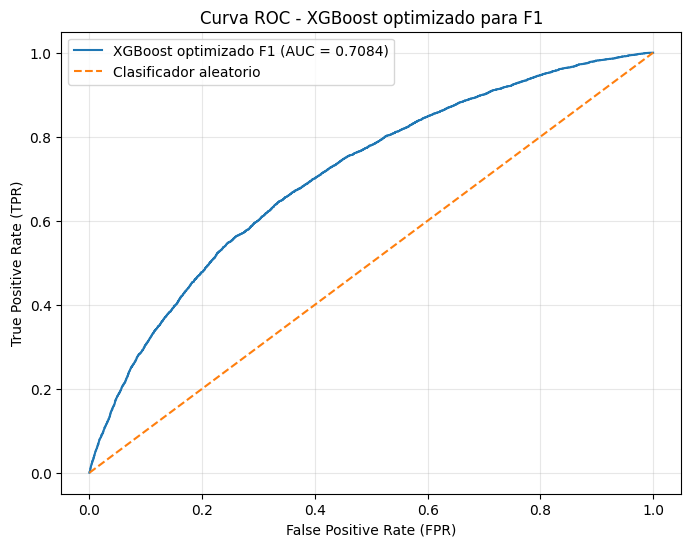

In [184]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob_xgb_f1
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f'XGBoost optimizado F1 (AUC = {roc_auc_xgb_f1:.4f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Clasificador aleatorio'
)

plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Curva ROC - XGBoost optimizado para F1')
plt.legend()
plt.grid(alpha=0.3)

plt.show()